In [69]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

The Abstract Problem Interface

In [70]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

The Node Class

In [71]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

 Helper Functions

In [72]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

Implementing the Grid Search Problem

In [ ]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        return state == self.goal

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        #
        # Steps:
        # 1. Create an empty list called legal_actions.
        legal_actions = []
        # 2. For each action in MOVES:
        #       a. Compute the neighbour cell.
        row, col = state
        for action, (dr, dc) in MOVES.items():
            neighbour = (row + dr, col + dc)

            #       b. Check that it is in bounds.
            if self.in_bounds(neighbour) and self.is_free(neighbour):
                #       c. Check that it is free.
                #       d. If valid, add the action name to legal_actions.
                legal_actions.append(action)
        # 3. Return legal_actions.
        return legal_actions
        raise NotImplementedError("Complete GridProblem.actions")

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        row, col = state
        dr, dc = MOVES[action]
        return (row + dr, col + dc)
        # Hint:
        # dr, dc = MOVES[action]
        # return (row + dr, col + dc)
        raise NotImplementedError("Complete GridProblem.result")

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        # Return 1.

        return 1.0

        raise NotImplementedError("Complete GridProblem.action_cost")

Self-Check for GridProblem

In [74]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
# assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


Sample Drone Map

sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

7. Visualisation Helper

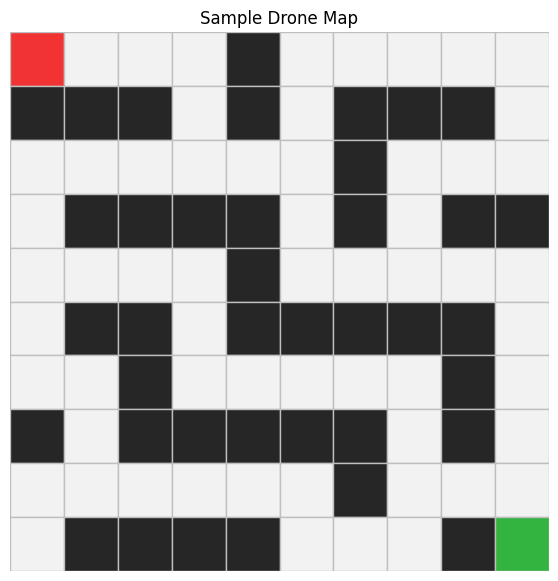

In [75]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)


def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()


plot_path(sample_grid, start, goal, title="Sample Drone Map")

8. The Shared expand Method

In [76]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:
        s = node.state
        # s <- node.STATE
        # for each action in problem.ACTIONS(s):
        for action in problem.actions(s):
            #     s_prime <- problem.RESULT(s, action)
            s_prime = problem.result(s, action)
            #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)
            #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)
            yield Node(state=s_prime, parent=node, action=action, path_cost=cost)

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

Breadth-First Search (BFS)

In [77]:
"Complete the BreadthFirstSearch.search method."


class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"
        nodes_expanded = 0
        max_frontier_size = 0

        # TODO 6:
        # Implement BFS graph search using a FIFO queue.
        #
        # Steps:
        # 1. Create the initial node from problem.initial_state().
        initial = Node(problem.initial_state())
        # 2. If the initial state is the goal, return success.
        if problem.is_goal(initial.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=initial,
                nodes_expanded=nodes_expanded,
                max_frontier_size=1,
                reached_count=0,
            )
        # 3. Create a deque frontier and add the initial node.
        frontier = deque([initial])
        # 4. Create a reached set and add the initial state.
        reached = set([initial.state])

        # 5. While frontier is not empty:
        while frontier:
            max_frontier_size = max(max_frontier_size, len(frontier))

            #       a. pop from the LEFT of the deque.
            node = frontier.popleft()

            #       b. increment nodes_expanded.
            nodes_expanded += 1
            #       c. expand the node.
            for child in self.expand(problem, node):
                #       d. for each child:
                #            i. if child is goal, return success.
                if problem.is_goal(child.state):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached),
                    )
                    #  ii. if child.state is not in reached:
                    #  add child.state to reached.
                    #   append child to frontier.
                if child.state not in reached:
                    reached.add(child.state)
                    frontier.append(child)

        #       e. update max_frontier_size.
        # 6. Return failure if no solution is found.
        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
        )

        #
        # Hint:
        # frontier = deque([node])
        # node = frontier.popleft()
        raise NotImplementedError("Complete BreadthFirstSearch.search")

10. Depth-First Search (DFS)

In [78]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        # TODO 7:
        # Implement DFS graph search using a stack.
        #
        # Steps:
        # 1. Create the initial node.

        nodes_expanded = 0
        max_frontier_size = 0

        # 2. If the initial state is the goal, return success
        initial = Node(problem.initial_state())
        if problem.is_goal(initial.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=initial,
                nodes_expanded=nodes_expanded,
                max_frontier_size=1,
                reached_count=0,
            )

        # 3. Use a Python list as the stack frontier.
        frontier = [initial]

        # 4. Use a reached set.
        reached = set([initial.state])
        # 5. While frontier is not empty:
        while frontier:
            max_frontier_size = max(max_frontier_size, len(frontier))
            #  a. pop from the end of the list.

            node = frontier.pop()
            # b. increment nodes_expanded.
            nodes_expanded += 1
            #  c. expand the node.
            for child in self.expand(problem, node):
                if problem.is_goal(child.state):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached),
                    )
                # d. add unreached children to the stack.
                # e. update max_frontier_size.
                if child.state not in reached:
                    reached.add(child.state)
                    frontier.append(child)

        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
        )

        #
        # Note:
        # If you want DFS to explore actions in the same order as MOVES,
        # you may need to reverse the children before pushing them.

Depth-Limited Search (DLS)

In [79]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        # TODO 8:
        # Implement recursive depth-limited search.
        #
        # Steps:
        # 1. If node.state is goal, return (node, "success").
        if problem.is_goal(node.state):
            return (node, "success")
        # 2. Else if node.depth >= limit, return (None, "cutoff").
        elif node.depth >= limit:
            return (None, "cutoff")
        # 3. Otherwise:
        else:
            #       a. increment metrics["nodes_expanded"].
            metrics["nodes_expanded"] += 1

            #       b. set cutoff_occurred = False.
            cutoff_occurred = False
            #       c. for each child in expand(problem, node):
            for child in self.expand(problem, node):
                #             i. skip the child if child.state already appears on the current path.
                if state_is_on_path(node, child.state):
                    continue
                #            ii. update max_stack_size.
                new_stack_size = current_stack_size + 1
                metrics["max_stack_size"] = max(
                    metrics["max_stack_size"], new_stack_size
                )
                #           iii. recursively call _recursive_dls on the child.
                result_node, result_status = self._recursive_dls(
                    problem=problem,
                    node=child,
                    limit=limit,
                    metrics=metrics,
                    current_stack_size=new_stack_size,
                )
                #            iv. if result is "success", return success immediately.
                if result_status == "success":
                    return (result_node, "success")
                #             v. if result is "cutoff", set cutoff_occurred = True.
                elif result_status == "cutoff":
                    cutoff_occurred = True
            #       d. after all children:
            #             if cutoff_occurred, return (None, "cutoff")
            if cutoff_occurred:
                return (None, "cutoff")
            #             else return (None, "failure")
            else:
                return (None, "failure")
        raise NotImplementedError("Complete DepthLimitedSearch._recursive_dls")

 Iterative Deepening Search (IDS)

In [80]:
from unittest import result


class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        # TODO 9:
        # Implement IDS by repeatedly running DLS from limit 0 to max_depth.

        #
        # Requirements:
        # 1. Keep a list called iteration_log.
        iteration_log = []
        # 2. Accumulate total nodes expanded across all DLS iterations.
        total_nodes_expanded = 0
        # 3. Track the maximum stack size seen in any DLS run.
        max_stack_size = 0
        dls = DepthLimitedSearch()
        for limit in range(max_depth + 1):
            dls = DepthLimitedSearch()
            result = dls.search(problem, limit=limit)
            total_nodes_expanded += result.nodes_expanded
            max_stack_size = max(max_stack_size, result.max_frontier_size)
            iteration_log.append(
                {
                    "limit": limit,
                    "nodes_expanded": result.nodes_expanded,
                    "max_stack_size": result.max_frontier_size,
                }
            )
            # 4. If a DLS run returns success, return a SearchResult for IDS.
            if result.status == "success":
                return SearchResult(
                    algorithm=algorithm,
                    status="success",
                    solution=result.solution,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_stack_size,
                    limit=limit,
                    reached_count=result.reached_count,
                    iterations=iteration_log,
                )

            # 5. If a DLS run returns failure, IDS can stop early and return failure.
            elif result.status == "failure":
                return SearchResult(
                    algorithm=algorithm,
                    status="failure",
                    solution=None,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_stack_size,
                    reached_count=result.reached_count,
                    iterations=iteration_log,
                    limit=limit,
                )
        # 6. If all limits return cutoff up to max_depth, return cutoff.
        return SearchResult(
            algorithm=algorithm,
            status="cutoff",
            solution=None,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=max_stack_size,
            reached_count=result.reached_count,
            iterations=iteration_log,
            limit=max_depth,
        )
        #
        # Hint:
        # dls = DepthLimitedSearch()
        # result = dls.search(problem, limit=limit)


Run the Algorithms on the Sample Map

In [81]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,50,5,52
1,DFS,success,NaN,18.0,18.0,18,4,21
2,DLS,cutoff,10.0,NaN,NaN,16,11,0
3,IDS,success,18.0,18.0,18.0,356,19,0


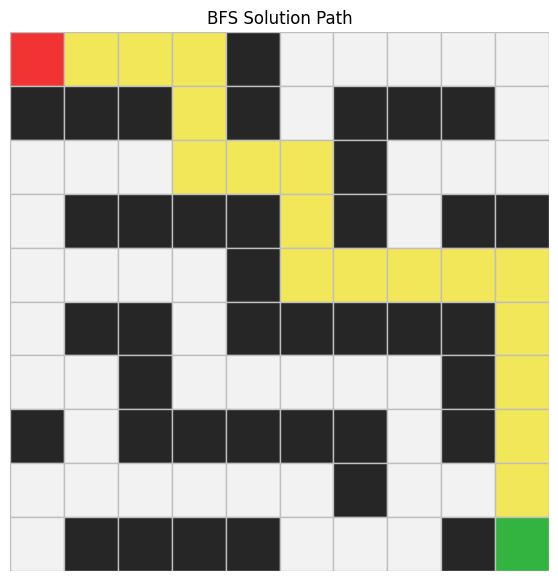

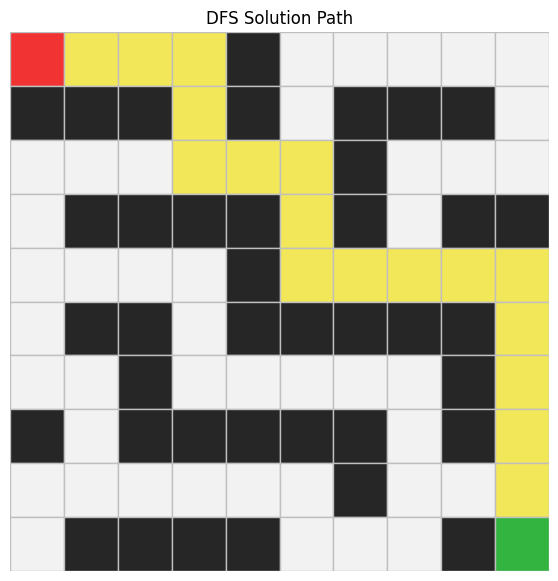

In [82]:
# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

 Create Your Own Maps

In [83]:
# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
    [0, 0, 0, 1, 0, 0, 1, 0, 0, 0],
    [0, 1, 0, 1, 0, 1, 1, 1, 1, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 1, 1],
    [1, 0, 0, 0, 0, 1, 0, 0, 0, 0],
]

custom_start_1 = (0, 0)
custom_goal_1 = (4, 9)
# Example after completing:
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40),
]
show_results(custom_results_1)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,13,13.0,20,3,20
1,DFS,success,NaN,13,13.0,14,4,16
2,DLS,success,20.0,13,13.0,19,14,0
3,IDS,success,13.0,13,13.0,142,14,0


In [84]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
    # Replace this with your own grid.
    [0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1],
    [0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1],
    [0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1],
    [0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1],
    [1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0],
    [1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0],
    [0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1],
    [0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1],
    [1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1],
]

custom_start_2 = (0, 0)
custom_goal_2 = (7, 6)

# Example after completing:
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=20),
    ids.search(custom_problem_2, max_depth=40),
]
show_results(custom_results_2)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,13,13.0,32,5,33
1,DFS,success,NaN,13,13.0,29,6,31
2,DLS,success,20.0,15,15.0,27,21,0
3,IDS,success,13.0,13,13.0,199,14,0


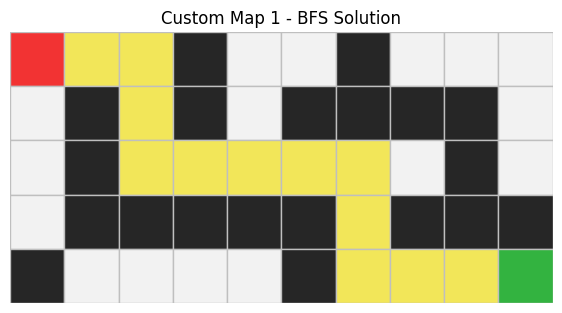

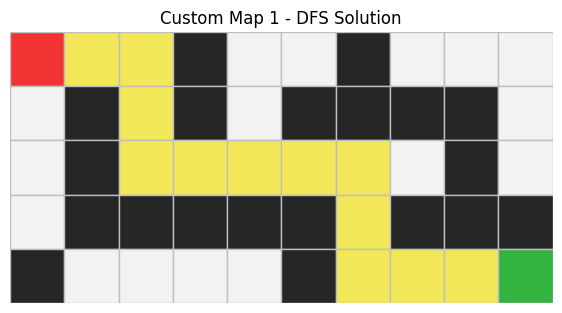

In [ ]:
plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[0].path,
    title="Custom Map 1 - BFS Solution",
)

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[1].path,
    title="Custom Map 1 - DFS Solution",
)


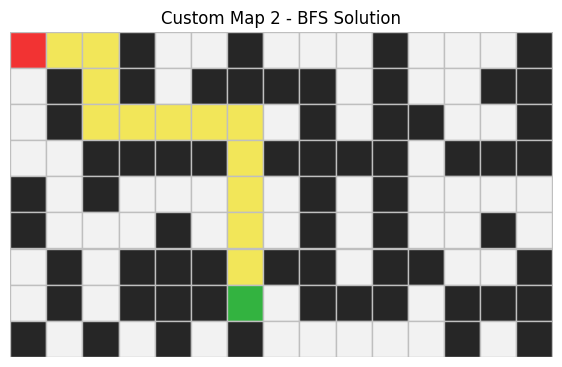

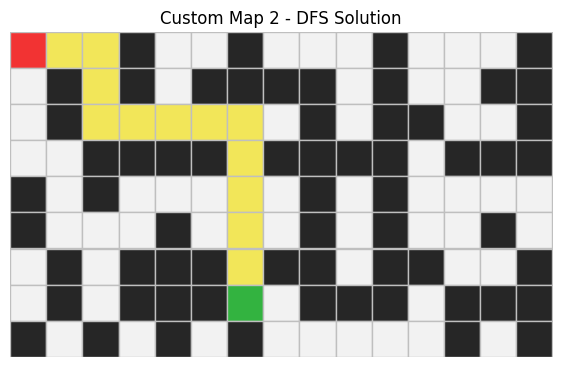

In [ ]:
plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[0].path,
    title="Custom Map 2 - BFS Solution",
)

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[1].path,
    title="Custom Map 2 - DFS Solution",
)

15.1 Problem Formulation
What is a state in this lab?
A state is the drones current location in the form of row,col

What is an action?
an action refers the directions a drone can take and those are up,down,left,right

What does the result function do?
it finds the new location of a drone 

Why is it useful to separate the problem definition from the search algorithm?
it will make the search algorithm useful for oother problems

15.2 BFS
Why does BFS use a FIFO queue?
The FIFO queue allows the BFS to search all the nodes at a depth before moving to the next 

Why does BFS find the shortest path in terms of number of steps on the unweighted grid?
BFS explores level by level so when it reaches the goal it knows the entire map above it so it can accurately choose the shortest path.

What role does the reached set play in BFS?
it prevents the bff from going to the same state twice

15.3 DFS
Why does DFS use a stack?
a stack allows the DFS to explore the a path to its deepest available level before going back because it has a last in first out rule.

Is DFS guaranteed to find the shortest path? Explain.
no, It explores every route to the deepest level, it can find the goal on that route instead of a shorter one depending on which it explores first. 

Under what conditions can DFS use less memory than BFS?
When the goal is deep in a search tree and has many branches

Under what conditions can DFS perform badly?
when the searches are deep lead to dead ends.

15.4 DLS
What happens when the depth limit is too small?
DlS returns "cuttoff"

What is the meaning of "cutoff"?
this is when the search stopped because a node got to the depth limit set.

How is DLS different from ordinary DFS?
DFS searches go deeper and deeper until it finds a solution or reaches a dead end while the DLS has a limit on how deep it can go 

Why do we use path-cycle checking in DLS?
Path cycling is used for IDS's because if a DLS reach set records a path it took before cutoff, when the IDS increases the depth limit the reach set will prevent the path from being taken but the path cycle makes sure that the blockage only happens for each cycle at the same depthlimit.

15.5 IDS
Why does IDS repeat DLS with increasing limits?
Because any limit  set could potentially be too small to reach the goal. increasing it guarantees success if the is a possible path.

Why can IDS be complete even though DLS with a small limit is not?
IDS keeps increasing the limit so the goal could be met eventually

Why does IDS use less memory than BFS?
IDS only keeps one path in memory at a time while the BFS stores the info of all nodes at the same time 

What is the cost of repeatedly searching from the root?



15.6 Real-World Drone Context
In a real drone application, what might make one route safer or more practical than another?

Which algorithm would you choose if all moves are equally costly and you only care about the fewest number of moves? Explain.
BFS because it gaurantees the shortest path.

Which algorithm would you choose if you want to limit how deep the drone is allowed to search? Explain.
DLS because it has a depth limit that can control how deep the drone will go

What limitations does this grid model have compared with real drone navigation?
It does not account for dynamic environments
it has a rigid set of moves

